In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Наложение и удаление шума

In [4]:
orig_img = cv2.imread('sar_1.jpg')
gray_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2GRAY)

In [5]:
# Гауссов шум
gauss_noise = np.random.normal(loc=0, scale=130, size=gray_img.shape)
noisy_gauss = np.clip(
    gray_img.astype(np.float32) + gauss_noise, 0, 255
).astype(np.uint8)

# Равномерный (постоянный) шум
# Значения шума равномерно распределяются в диапазоне [-130, 130]
uniform_noise = np.random.uniform(-130, 130, size=gray_img.shape)
noisy_uniform = np.clip(
    gray_img.astype(np.float32) + uniform_noise, 0, 255
).astype(np.uint8)


In [6]:
# Фильтр Гаусса: ядро 21x21 и 31x31
gauss_f1 = cv2.GaussianBlur(noisy_gauss, (21, 21), sigmaX=5.0)
gauss_f2 = cv2.GaussianBlur(noisy_gauss, (31, 31), sigmaX=10.0)

# Медианный фильтр: окно 9 и 15
median_f1 = cv2.medianBlur(noisy_uniform, 9)
median_f2 = cv2.medianBlur(noisy_uniform, 15)

# Билатеральный фильтр
bilat_f1 = cv2.bilateralFilter(
    noisy_gauss, d=15, sigmaColor=150, sigmaSpace=150
)
bilat_f2 = cv2.bilateralFilter(
    noisy_gauss, d=25, sigmaColor=250, sigmaSpace=250
)

# Фильтр нелокальных средних
nlm_f1 = cv2.fastNlMeansDenoising(
    noisy_gauss, h=50, templateWindowSize=7, searchWindowSize=21
)
nlm_f2 = cv2.fastNlMeansDenoising(
    noisy_gauss, h=80, templateWindowSize=7, searchWindowSize=21
)


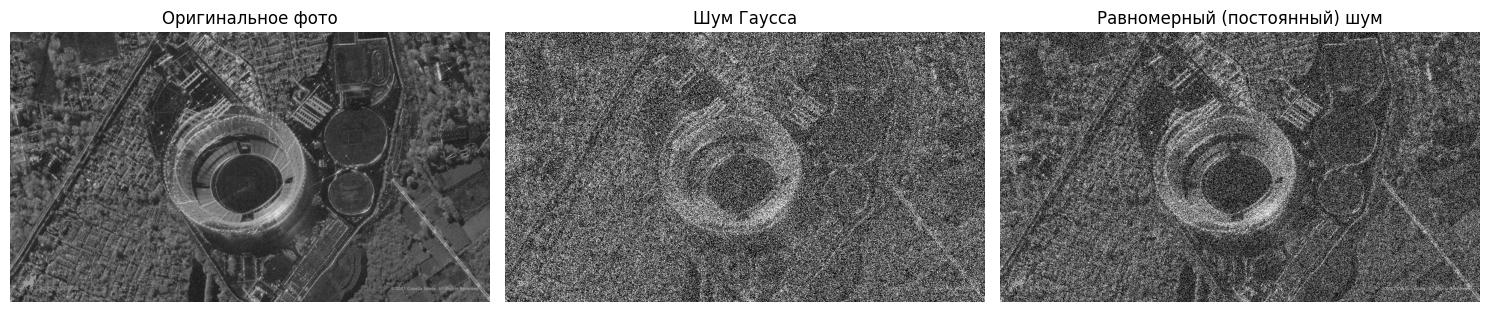

In [7]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.title("Оригинальное фото")
plt.imshow(gray_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Шум Гаусса")
plt.imshow(noisy_gauss, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Равномерный (постоянный) шум")
plt.imshow(noisy_uniform, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


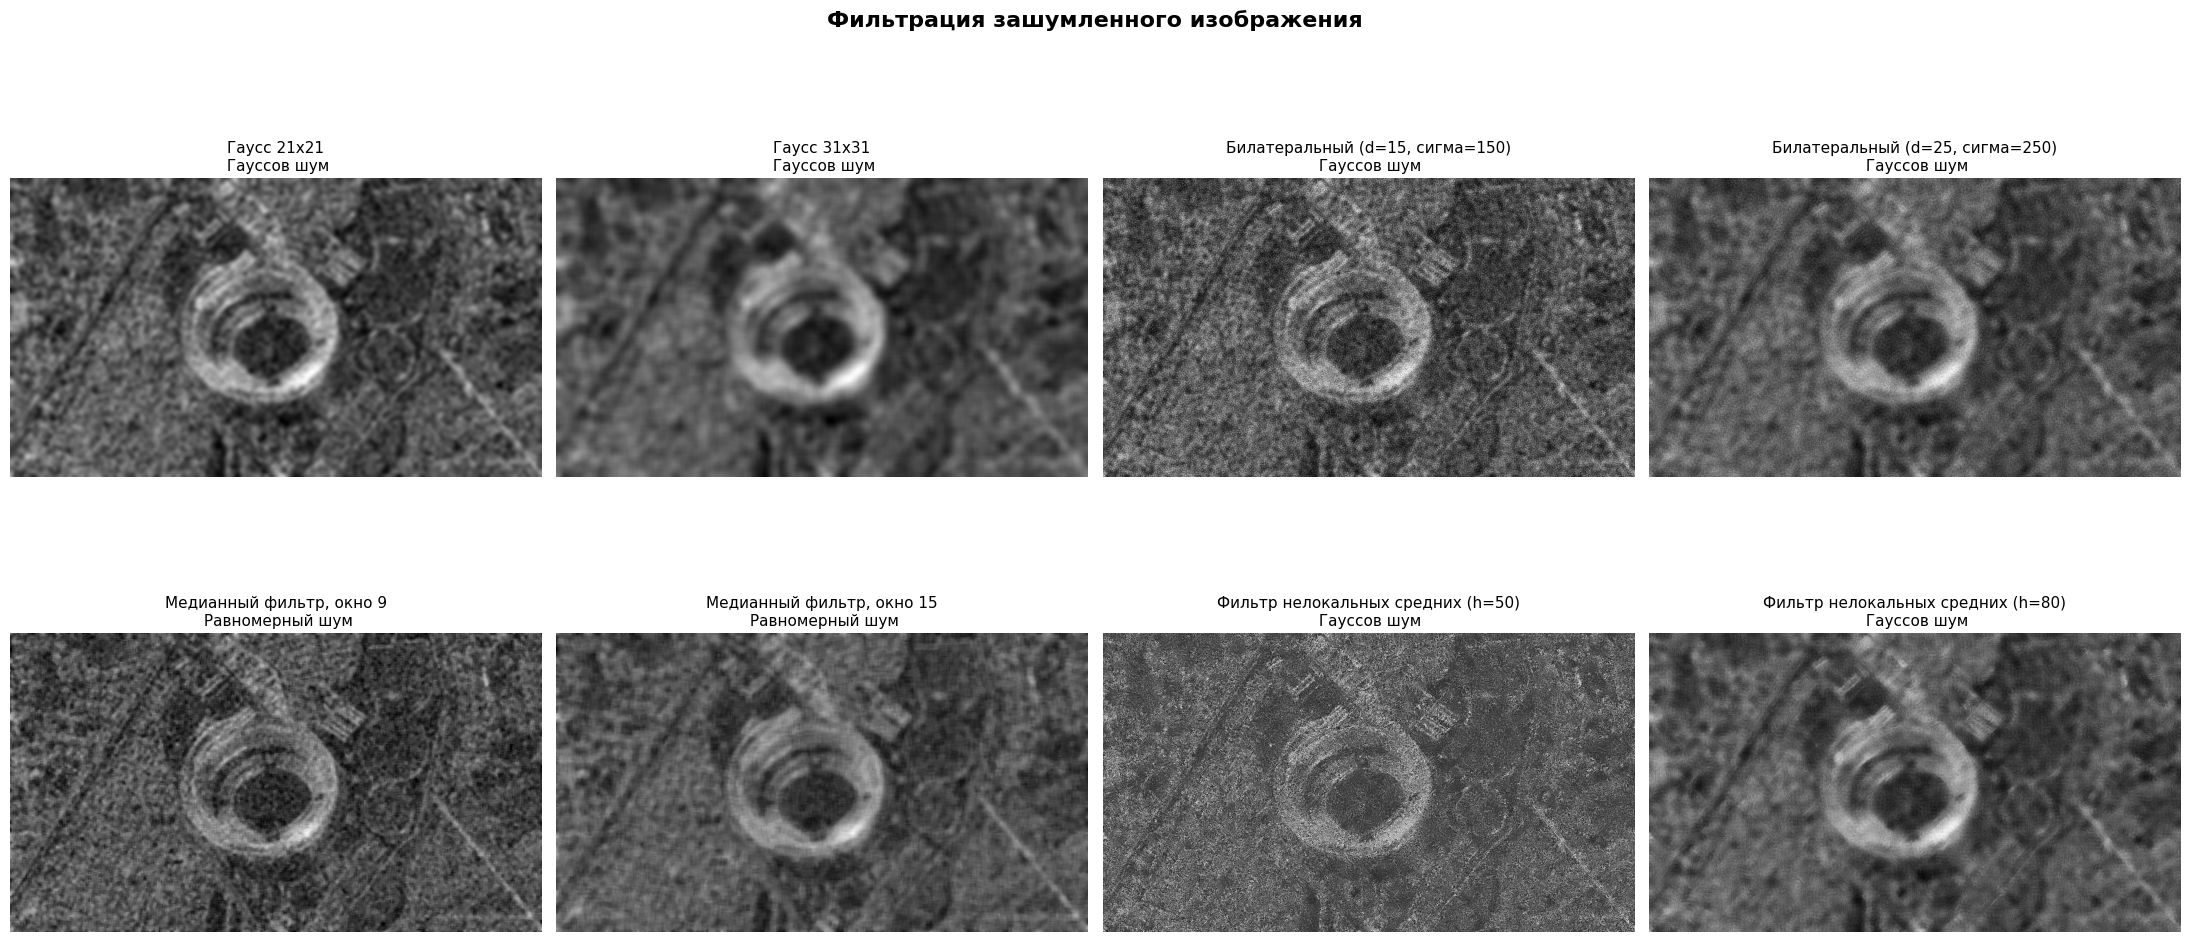

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle("Фильтрация зашумленного изображения", fontsize=16, fontweight='bold')

filter_results = [
    (gauss_f1, "Гаусс 21x21\n Гауссов шум"),
    (gauss_f2, "Гаусс 31x31\n Гауссов шум"),
    (bilat_f1, "Билатеральный (d=15, сигма=150)\n Гауссов шум"),
    (bilat_f2, "Билатеральный (d=25, сигма=250)\n Гауссов шум"),
    (median_f1, "Медианный фильтр, окно 9\n Равномерный шум"),
    (median_f2, "Медианный фильтр, окно 15\n Равномерный шум"),
    (nlm_f1, "Фильтр нелокальных средних (h=50)\n Гауссов шум"),
    (nlm_f2, "Фильтр нелокальных средних (h=80)\n Гауссов шум")
]

for ax, (img, name) in zip(axes.ravel(), filter_results):
    ax.imshow(img, cmap='gray')
    ax.set_title(name, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [9]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse

print("Оценка фильтрации гауссова шума")
print(f"NL-Means h=80 -> MSE: {mse(gray_img, nlm_f2):.2f}, SSIM: {ssim(gray_img, nlm_f2):.3f}")
print(f"Билатеральный d=25 -> MSE: {mse(gray_img, bilat_f2):.2f}, SSIM: {ssim(gray_img, bilat_f2):.3f}")

print("\nОценка фильтрации равномерного (постоянного) шума")
print(f"Медианный k=9 -> MSE: {mse(gray_img, median_f1):.2f}, SSIM: {ssim(gray_img, median_f1):.3f}")
print(f"Медианный k=15 -> MSE: {mse(gray_img, median_f2):.2f}, SSIM: {ssim(gray_img, median_f2):.3f}")

print("\nВЫВОД:")
print("1. Для гауссова шума в данной работе сравниваются фильтры нелокальных средних и билатеральный фильтр.")
print("2. Для равномерного (постоянного) шума проверяется работа медианного фильтра с разными размерами окна.")
print("3. Лучший результат определяется по меньшему MSE и большему SSIM.")


Оценка фильтрации гауссова шума
NL-Means h=80 -> MSE: 826.42, SSIM: 0.265
Билатеральный d=25 -> MSE: 849.41, SSIM: 0.240

Оценка фильтрации равномерного (постоянного) шума
Медианный k=9 -> MSE: 518.99, SSIM: 0.305
Медианный k=15 -> MSE: 507.00, SSIM: 0.270

ВЫВОД:
1. Для гауссова шума в данной работе сравниваются фильтры нелокальных средних и билатеральный фильтр.
2. Для равномерного (постоянного) шума проверяется работа медианного фильтра с разными размерами окна.
3. Лучший результат определяется по меньшему MSE и большему SSIM.


In [10]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.